In [ ]:
import pandas as pd
import numpy as np
df_reward = pd.read_csv("reward_dataframe.csv")
tab_reward = [[] for _ in range(10)]
for i in range(10):
    tab_reward[i] = df_reward[str(i)].values

tab_reward[0]

In [32]:
def id_to_strategy(id):
    strategy = [0 for _ in range(10)]
    i = 0
    while id > 0:
        if id % 2 == 1:
            strategy[9-i] = 1
        id = id//2
        i += 1
    return strategy


def strategy_to_id(s):
    id = 0
    for i in range(10):
        id += s[i]*(2**(9-i))
    return id

In [44]:
def neighbouring_strategies(s):
    neigh = [ [s[j] for j in range(10)] for _ in range(10)]
    for i in range(10):
        neigh[i][i] = 1 - neigh[i][i]
    return neigh

def neighbouring_ids(id):
    s = id_to_strategy(id)
    t = neighbouring_strategies(s)
    neigh = []
    for i in range(10):
        neigh.append(strategy_to_id(t[i]))
    return neigh

In [ ]:
def reward(i,id):
    return float(tab_reward[i][id])

def id_to_reward(id):
    return [reward(i,id) for i in range(10)]

def s_to_reward(s):
    id = strategy_to_id(s)
    return id_to_reward(id)

In [79]:
def nash_deviation(s):
    rew = s_to_reward(s)
    neigh = neighbouring_strategies(s)
    dev = []
    for i in range(10):
        alternative = s_to_reward(neigh[i])[i]
        dev.append(alternative - rew[i])
    return dev

def nash_equilibrium(s):
    dev = nash_deviation(s)
    for i in range(1,10):
        # we do not verify if the first AV can deviate. Otherwise, no non-trivial NE will be found.
        if dev[i] > 0:
            return False
    return True

def nash_equilibrium_eps(s,eps=0):
    dev = nash_deviation(s)
    for i in range(1,10):
        # we do not verify if the first AV can deviate. Otherwise, no non-trivial NE will be found.
        if dev[i] > eps:
            return False
    return True

In [82]:
P = [[2,3,5],[0,1,9,8],[4],[6,7]]

In [88]:
def id_to_reward_coalition(id,coalition):
    sum = 0
    nb = 0
    for i in coalition:
        sum += reward(i,id)
        nb += 1
    return sum/nb

def s_to_reward_coalition(s,coalition):
    id = strategy_to_id(s)
    return id_to_reward_coalition(id,coalition)

def id_to_reward_partition(id,partition):
    return [id_to_reward_coalition(id,coalition) for coalition in partition]

def s_to_reward_partition(s,partition):
    id = strategy_to_id(s)
    return id_to_reward_partition(id,partition)

def tab_reward_partition(partition):
    tab = []
    for id in range(1024):
        tab.append(id_to_reward_partition(id,partition))
    return [[tab[id][c] for id in range(1024)] for c in range(len(partition))]

In [103]:
def compatible_strategies(coalition,x):
    '''
    coalition is a table of k indexes from [n]
    x is a table of k bits

    output is the table of strategies where forall i in [k], s[coalition[i]] == x[i]
    '''
    k = len(coalition)
    comp = []
    id = 0
    while id < 1024:
        s = id_to_strategy(id)
        i = 0
        while i<k and (s[coalition[i]] == x[i]):
            i += 1
        if i == k:
            comp.append(s)
        id += 1
    return comp

def compatible_ids(coalition,id):
    s = id_to_strategy(id)
    x = [s[i] for i in coalition]
    comp_s = compatible_strategies(coalition,x)
    return [strategy_to_id(t) for t in comp_s]

In [138]:
def coalition_to_strategy(coalition):
    s = [0 for _ in range(10)]
    for i in coalition:
        s[i] = 1
    return s

def strategy_to_coalition(s):
    coalition = []
    for i in range(10):
        if s[i] == 1:
            coalition.append(i)
    return coalition

In [ ]:
def reward_coalition_strategy(coalition,x):
    s_comp = compatible_strategies(coalition,x)
    rew = 0
    for s in s_comp:
        g = s_to_reward_coalition(s,coalition)
        if g < rew:
            rew = g
    return rew

def worth_coalition(coalition):
    k = len(coalition)
    rew = -1e5
    best_x = [0 for _ in range(k)]
    for id in range(2**k):
        x = [(id//(2**i))%2 for i in range(k)]
        v = reward_coalition_strategy(coalition,x)
        if v > rew:
            rew = v
            best_x = x
    return rew

tab_worth = [-1e-5]
for id in range(1,1024):
    c = strategy_to_coalition(id_to_strategy(id))
    tab_worth.append(worth_coalition(c))
tab_worth


In [194]:

def search_worth(coalition):
    return tab_worth[strategy_to_id(coalition_to_strategy(coalition))]

def worth_coalition_partition(partition):
    return [search_worth(coalition) for coalition in partition]

In [ ]:
def internal_stability(coalition):
    v = search_worth(coalition)
    for i in coalition:
        if worth_coalition([i]) > v:
            print("not internally stable,", i, "quits")
            return False
    return True

def stability(coalition):
    s = coalition_to_strategy(coalition)
    v = search_worth(coalition)
    for i in range(10):
        if s[i] == 1:
            s[i] = 0
            cprime = strategy_to_coalition(s)
            if len(cprime) > 0:
                if search_worth(cprime) > v:
                    print("not internally stable,", i, "is kicked")
                    return False
                if search_worth([i]) > v:
                    print("not internally stable,", i, "quits")
                    return False
            s[i] = 1
        if s[i] == 0:
            s[i] = 1
            cprime = strategy_to_coalition(s)
            if search_worth(cprime) > v and search_worth(cprime) > search_worth([i]):
                print("not externally stable,", i, "joins")
                return False
            s[i] = 0
    return True

def partition_stability(partition):
    s_list = [coalition_to_strategy(coalition) for coalition in partition]
    v_list = worth_coalition_partition(partition)
    for j in range(len(s_list)):
        c = partition[j]
        s = s_list[j]
        v = v_list[j]
        for i in c:
            s[i] = 0
            cprime = strategy_to_coalition(s)
            if len(cprime) > 0:
                if search_worth(cprime) > v:
                    # print("not internally stable,", i, "is kicked")
                    return False
                if search_worth([i]) > v:
                    # print("not internally stable,", i, "quits")
                    return False
            s[i] = 1
        for k in range(len(s_list)):
            ck = partition[k]
            sk = s_list[k]
            vk = v_list[k]
            for i in ck:
                s[i] = 1
                cprime = strategy_to_coalition(s)
                if search_worth(cprime) > v and search_worth(cprime) > vk:
                    # print("not externally stable,", i, "moves to", j)
                    return False
                s[i] = 0
    return True


In [201]:
def partition_stability_eps(partition):
    cost_kick, cost_isol, cost_comm, cost_move = 0,0,0,0
    s_list = [coalition_to_strategy(coalition) for coalition in partition]
    v_list = worth_coalition_partition(partition)
    for j in range(len(s_list)):
        c = partition[j]
        s = s_list[j]
        v = v_list[j]
        for i in c:
            s[i] = 0
            cprime = strategy_to_coalition(s)
            if len(cprime) > 0:
                if search_worth(cprime) - v > cost_kick:
                    cost_kick = search_worth(cprime) - v
                if search_worth([i]) - v > cost_isol:
                    cost_isol = search_worth([i]) - v
            s[i] = 1
        for k in range(len(s_list)):
            ck = partition[k]
            sk = s_list[k]
            vk = v_list[k]
            for i in ck:
                s[i] = 1
                cprime = strategy_to_coalition(s)
                if search_worth(cprime) - v > cost_comm and search_worth(cprime)-vk > cost_move:
                    # print("not externally stable,", i, "moves to", j)
                    if search_worth(cprime) - v > cost_comm:
                        cost_comm = search_worth(cprime) - v
                    if search_worth(cprime)-vk > cost_move:
                        cost_move = search_worth(cprime)-vk
                s[i] = 0
    return cost_kick, cost_isol, cost_comm, cost_move

In [196]:
stable = []
for id in range(1,1024):
    print(id)
    coalition = strategy_to_coalition(id_to_strategy(id))
    if stability(coalition):
        stable.append(id)
stable

1
2
not externally stable, 7 joins
3
not internally stable, 8 quits
4
not externally stable, 8 joins
5
not internally stable, 7 quits
6
7
not internally stable, 7 quits
8
9
not internally stable, 6 quits
10
not internally stable, 6 quits
11
not internally stable, 6 quits
12
not internally stable, 6 quits
13
not internally stable, 6 quits
14
not internally stable, 6 quits
15
not internally stable, 6 quits
16
17
not internally stable, 5 quits
18
not internally stable, 5 quits
19
not internally stable, 5 quits
20
not internally stable, 5 quits
21
not internally stable, 5 quits
22
not internally stable, 5 quits
23
not internally stable, 5 quits
24
not internally stable, 5 quits
25
not internally stable, 5 quits
26
not internally stable, 5 quits
27
not internally stable, 5 quits
28
not internally stable, 5 quits
29
not internally stable, 5 quits
30
not internally stable, 5 quits
31
not internally stable, 5 quits
32
33
not internally stable, 4 quits
34
not internally stable, 4 quits
35
not i

[1, 6, 8, 16, 32, 64, 384, 512]

In [197]:
[strategy_to_coalition(id_to_strategy(id)) for id in stable]

[[9], [7, 8], [6], [5], [4], [3], [1, 2], [0]]

In [198]:
partition_stability([[0],[1,2],[3],[4],[5],[6],[7,8],[9]])

True

In [180]:
def partitions(ensemble):
    if len(ensemble) == 0:
        yield []
        return

    premier = ensemble[0]
    for partition in partitions(ensemble[1:]):
        # Insérer le premier élément dans chaque sous-ensemble de la partition
        for i in range(len(partition)):
            yield partition[:i] + [[premier] + partition[i]] + partition[i+1:]
        # Créer un nouveau sous-ensemble pour le premier élément
        yield [[premier]] + partition

# Exemple d'utilisation pour l'ensemble [0, 1, 2, ..., 9]
ensemble = list(range(10))
partitions_list = list(partitions(ensemble))

# Afficher le nombre total de partitions et quelques exemples
print(f"Nombre total de partitions : {len(partitions_list)}")
print("Quelques exemples de partitions :")
for p in partitions_list[:49]:  # Afficher seulement les 5 premières partitions
    print(p)

Nombre total de partitions : 115975
Quelques exemples de partitions :
[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]]
[[0], [1, 2, 3, 4, 5, 6, 7, 8, 9]]
[[0, 1], [2, 3, 4, 5, 6, 7, 8, 9]]
[[1], [0, 2, 3, 4, 5, 6, 7, 8, 9]]
[[0], [1], [2, 3, 4, 5, 6, 7, 8, 9]]
[[0, 1, 2], [3, 4, 5, 6, 7, 8, 9]]
[[1, 2], [0, 3, 4, 5, 6, 7, 8, 9]]
[[0], [1, 2], [3, 4, 5, 6, 7, 8, 9]]
[[0, 2], [1, 3, 4, 5, 6, 7, 8, 9]]
[[2], [0, 1, 3, 4, 5, 6, 7, 8, 9]]
[[0], [2], [1, 3, 4, 5, 6, 7, 8, 9]]
[[0, 1], [2], [3, 4, 5, 6, 7, 8, 9]]
[[1], [0, 2], [3, 4, 5, 6, 7, 8, 9]]
[[1], [2], [0, 3, 4, 5, 6, 7, 8, 9]]
[[0], [1], [2], [3, 4, 5, 6, 7, 8, 9]]
[[0, 1, 2, 3], [4, 5, 6, 7, 8, 9]]
[[1, 2, 3], [0, 4, 5, 6, 7, 8, 9]]
[[0], [1, 2, 3], [4, 5, 6, 7, 8, 9]]
[[0, 2, 3], [1, 4, 5, 6, 7, 8, 9]]
[[2, 3], [0, 1, 4, 5, 6, 7, 8, 9]]
[[0], [2, 3], [1, 4, 5, 6, 7, 8, 9]]
[[0, 1], [2, 3], [4, 5, 6, 7, 8, 9]]
[[1], [0, 2, 3], [4, 5, 6, 7, 8, 9]]
[[1], [2, 3], [0, 4, 5, 6, 7, 8, 9]]
[[0], [1], [2, 3], [4, 5, 6, 7, 8, 9]]
[[0, 1, 3], [2, 4, 5, 6, 7,

In [199]:
stab_p = []
i=0
for p in partitions_list:
    i += 1
    if partition_stability(p):
        stab_p.append(p)
    if i%100 == 0:
        print(i, "faits,", len(stab_p), "partitions stables trouvées")
print(len(stab_p))

100 faits, 0 partitions stables trouvées
200 faits, 0 partitions stables trouvées
300 faits, 0 partitions stables trouvées
400 faits, 0 partitions stables trouvées
500 faits, 0 partitions stables trouvées
600 faits, 0 partitions stables trouvées
700 faits, 0 partitions stables trouvées
800 faits, 0 partitions stables trouvées
900 faits, 0 partitions stables trouvées
1000 faits, 0 partitions stables trouvées
1100 faits, 0 partitions stables trouvées
1200 faits, 0 partitions stables trouvées
1300 faits, 0 partitions stables trouvées
1400 faits, 0 partitions stables trouvées
1500 faits, 0 partitions stables trouvées
1600 faits, 0 partitions stables trouvées
1700 faits, 0 partitions stables trouvées
1800 faits, 0 partitions stables trouvées
1900 faits, 0 partitions stables trouvées
2000 faits, 0 partitions stables trouvées
2100 faits, 0 partitions stables trouvées
2200 faits, 0 partitions stables trouvées
2300 faits, 0 partitions stables trouvées
2400 faits, 0 partitions stables trouvées
2

In [205]:
i=0
kick, isol, comm, move = [], [], [], []
for p in partitions_list:
    i += 1
    cost_kick, cost_isol, cost_comm, cost_move = partition_stability_eps(p)
    kick.append(cost_kick)
    isol.append(cost_isol)
    comm.append(cost_comm)
    move.append(cost_move)
    if i%10000 == 0:
        print(i, "faits")

10000 faits
20000 faits
30000 faits
40000 faits
50000 faits
60000 faits
70000 faits
80000 faits
90000 faits
100000 faits
110000 faits


In [200]:
stab_p

[[[0], [1, 2], [3], [4], [5], [6], [7, 8], [9]]]

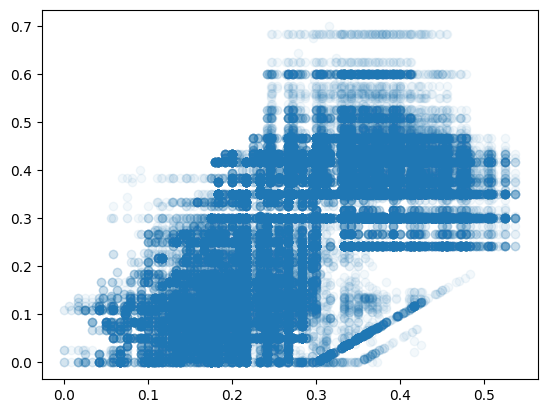

In [215]:
import matplotlib.pyplot as plt
plt.scatter(np.array(isol),np.array(comm),alpha=0.05)
plt.show()